In [1]:
import pandas as pd

df = pd.read_csv("../data/student_data.csv")

df.head()

,student_id,study_hours_per_day,attendance_percent,previous_score,assignment_completion_percent,sleep_hours,extracurricular,final_score
0,1,6.8,56,82,57,5.6,0,63.3
1,2,9.0,60,72,67,4.6,0,60.9
2,3,3.0,87,73,41,7.0,1,60.3
3,4,8.3,55,83,91,5.2,1,79.2
4,5,4.1,64,48,88,6.0,0,51.4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     10 non-null     int64  
 1   study_hours_per_day            10 non-null     float64
 2   attendance_percent             10 non-null     int64  
 3   previous_score                 10 non-null     int64  
 4   assignment_completion_percent  10 non-null     int64  
 5   sleep_hours                    10 non-null     float64
 6   extracurricular                10 non-null     int64  
 7   final_score                    10 non-null     float64
dtypes: float64(3), int64(5)
memory usage: 772.0 bytes


In [3]:
df.describe()

,student_id,study_hours_per_day,attendance_percent,previous_score,assignment_completion_percent,sleep_hours,extracurricular,final_score
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,6.000000,71.600000,72.200000,73.800000,6.210000,0.500000,67.120000
std,3.02765,2.326657,13.158858,14.273519,16.751783,0.906091,0.527046,12.825305
min,1.00000,2.800000,55.000000,48.000000,41.000000,4.600000,0.000000,51.400000
25%,3.25000,4.225000,61.000000,63.000000,64.000000,5.675000,0.000000,60.450000
50%,5.50000,6.150000,70.000000,72.500000,77.500000,6.250000,0.500000,62.250000
75%,7.75000,8.025000,83.250000,82.750000,86.500000,6.950000,1.000000,77.525000
max,10.00000,9.000000,91.000000,91.000000,94.000000,7.400000,1.000000,88.600000


In [4]:
df.isnull().sum()

student_id                       0
study_hours_per_day              0
attendance_percent               0
previous_score                   0
assignment_completion_percent    0
sleep_hours                      0
extracurricular                  0
final_score                      0
dtype: int64

In [5]:
df.corr(numeric_only=True)

,student_id,study_hours_per_day,attendance_percent,previous_score,assignment_completion_percent,sleep_hours,extracurricular,final_score
student_id,1.000000,-0.222402,0.482480,-0.141411,0.488535,0.556907,0.104447,0.231490
study_hours_per_day,-0.222402,1.000000,-0.261663,0.620303,0.478076,-0.343111,0.244647,0.636690
attendance_percent,0.482480,-0.261663,1.000000,0.273188,-0.076012,0.920155,0.608799,0.402713
previous_score,-0.141411,0.620303,0.273188,1.000000,0.078254,0.213750,0.635106,0.864345
assignment_completion_percent,0.488535,0.478076,-0.076012,0.078254,1.000000,0.038212,0.188773,0.497223
sleep_hours,0.556907,-0.343111,0.920155,0.213750,0.038212,1.000000,0.570037,0.394290
extracurricular,0.104447,0.244647,0.608799,0.635106,0.188773,0.570037,1.000000,0.774216
final_score,0.231490,0.636690,0.402713,0.864345,0.497223,0.394290,0.774216,1.000000


In [8]:
%pip install seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Seaborn working!")

Seaborn working!


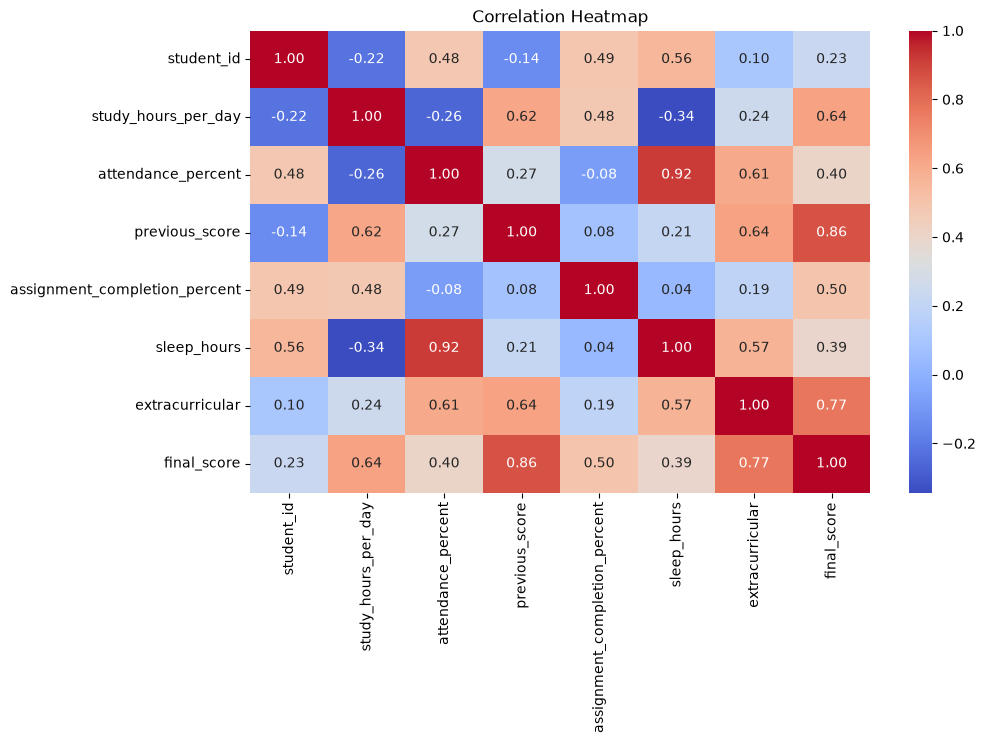

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = df.drop(columns=["student_id", "final_score"])
y = df["final_score"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['study_hours_per_day', 'attendance_percent', 'previous_score',
       'assignment_completion_percent', 'sleep_hours', 'extracurricular'],
      dtype='str')

Target:
final_score


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

ModuleNotFoundError: No module named 'sklearn'